# Titanic Survival Prediction — End-to-End ML Project

A complete machine learning project built the way a professional would build it.

**How to use this notebook:** run the cells in order. Each section explains
*why* it exists, not just what the code does. The commentary is the lesson.

| Step | What happens | The point |
|---|---|---|
| 0 Frame | Define target, metric, baseline | Beat the baseline or go home |
| 1 Explore | Split **first**, then EDA | Snooping bias contaminates your judgement |
| 2 Engineer | Title, FamilySize, HasCabin, log-fare, ticket group | The largest source of gains |
| 3 Compare | 8+ models, cross-validated, 3 metrics | Breadth first, depth later |
| 4 Tune | Random search, then test **once** | Training score should *fall* |
| 5 Ship | Save pipeline, validate, monitor | Where real projects fail |

**Runtime:** about 12–18 minutes total. Section 4 is the slow part.

**One knob worth knowing about:** `METRIC` in the setup cell. Everything
— model comparison, tuning, the final ranking — is scored with it. Set it to
`"f1"` or `"roc_auc"` and re-run from Step 3 to see whether a different
model wins.

---

## Setup

In [1]:
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_validate, StratifiedKFold,
                                     RandomizedSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             RocCurveDisplay, get_scorer)
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform

# Optional gradient-boosting libraries. Everything below works without them;
# if they are installed they join the model comparison and the tuning search.
#     pip install xgboost lightgbm
BOOSTERS = {}
try:
    from xgboost import XGBClassifier
    BOOSTERS["XGBoost"] = XGBClassifier
except ImportError:
    pass
try:
    from lightgbm import LGBMClassifier
    BOOSTERS["LightGBM"] = LGBMClassifier
except ImportError:
    pass

# ── THE SELECTION METRIC ──────────────────────────────────────────────────
# Model comparison (Step 3), the hyperparameter search (Step 4) and the final
# ranking all optimise THIS. Change it and re-run from Step 3.
#   "accuracy" - every mistake costs the same
#   "f1"       - balances precision and recall, ignores true negatives
#   "roc_auc"  - ranking quality, threshold-free
METRIC = "accuracy"
SCORER = get_scorer(METRIC)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)
%matplotlib inline

print("Setup complete.")
print(f"selection metric : {METRIC}")
print("boosters         :", ", ".join(BOOSTERS) or "none installed")

Setup complete.
selection metric : accuracy
boosters         : XGBoost


---
# Step 0 — Frame the Problem, Get the Data

Before writing code, answer these:

| Question | Answer |
|---|---|
| Business objective? | Predict survival from passenger details |
| Supervised or unsupervised? | **Supervised** — we have labelled outcomes |
| Classification or regression? | **Classification** — survived (1) or not (0) |
| Metric? | Whatever `METRIC` is set to — accuracy by default, plus precision/recall/AUC reported |
| **Baseline?** | Predict "everyone died" — we compute it below |

**Why the baseline matters most:** an accuracy figure without a baseline is
meaningless. If 62% of passengers died, a model scoring 60% is *worse than
useless*.

### Getting the data

If you have the real Kaggle file
([kaggle.com/c/titanic/data](https://www.kaggle.com/c/titanic/data)), upload
`train.csv` and the next cell will use it.

Otherwise it generates a stand-in that reproduces the real dataset's
statistical structure — same size, same survival rates by sex and class, same
missing-value pattern, same fare skew, same titles hidden in `Name`.

In [2]:
# ── Data loader: uses the real train.csv if present, else generates one ──
RNG = np.random.default_rng(42)
N = 891

MALE_FIRST = ["Owen","William","James","Henry","Arthur","Charles","Edward","John",
              "Thomas","George","Frederick","Albert","Ernest","Harry","Joseph",
              "Samuel","Walter","Alfred","Robert","Karl","Anders","Johan","Nils"]
FEMALE_FIRST = ["Elizabeth","Florence","Laina","Lily","Anna","Margaret","Helen",
                "Constance","Ellen","Bertha","Alice","Hilda","Eleanor","Nora",
                "Emily","Bridget","Maria","Agnes","Ada","Kate","Ruth","Edith"]
SURNAMES = ["Braund","Cumings","Heikkinen","Futrelle","Allen","Moran","McCarthy",
            "Palsson","Johnson","Nasser","Sandstrom","Bonnell","Andersson",
            "Vestrom","Hewlett","Rice","Williams","Fynney","Beesley","McGowan",
            "Asplund","Fortune","Spencer","Glynn","Meyer","Ford","Woolner",
            "Ostby","Goodwin","Harris","Skoog","Carrau","Panula","Harper"]

def _pick(opts):
    return opts[RNG.integers(0, len(opts))]

def _make_name(sex, age, rare):
    surname = _pick(SURNAMES)
    if rare:
        title = _pick(["Dr","Rev","Col","Major","Capt","Don","Sir"]) if sex == "male" \
                else _pick(["Dr","Lady","Countess","Mme","Mlle","Ms"])
    elif sex == "male":
        title = "Master" if age < 13 else "Mr"
    else:
        title = "Mrs" if (age >= 25 and RNG.random() < 0.62) else "Miss"
    first = _pick(MALE_FIRST if sex == "male" else FEMALE_FIRST)
    return f"{surname}, {title}. {first}"

# Ticket prefixes in the real data are not random: "PC" tickets are almost all
# first class. Reproducing that gives TicketPrefix something real to find.
TICKET_POOLS = {1: ["PC", "PC", "", "", "A/5"],
                2: ["C.A.", "", "", "SOTON/OQ"],
                3: ["A/5", "STON/O2.", "", "", "SOTON/OQ", "W./C."]}

def _assign_tickets(frame):
    """Families and travelling companions SHARE a ticket number.

    Without this the Ticket column is pure noise and the group-size feature
    engineered in Step 2 has nothing to recover.
    """
    tickets, pools = [], {}
    for r in frame.itertuples(index=False):
        surname = r.Name.split(",")[0]
        fam = r.SibSp + r.Parch + 1
        key = (surname, r.Pclass)

        # A party has a FIXED number of seats. Without this cap every
        # same-surname passenger piles onto one ticket and the stand-in ends
        # up with twice the real rate of shared tickets.
        # Not every family travelled on one ticket, so sharing is probabilistic.
        # These two numbers are tuned to land near the real 0.353 share rate.
        joins = RNG.random() < (0.68 if fam > 1 else 0.03)
        if key in pools and pools[key][1] > 0 and joins:
            t, slots = pools[key]
            pools[key] = (t, slots - 1)
            tickets.append(t)                     # same party, one ticket
            continue

        t = f"{_pick(TICKET_POOLS[r.Pclass])} {RNG.integers(1000, 400000)}".strip()
        if fam > 1:
            pools[key] = (t, fam - 1)
        tickets.append(t)
    return tickets


def generate_titanic():
    """Reproduces the real dataset's statistical structure."""
    pclass = RNG.choice([1,2,3], size=N, p=[216/N, 184/N, 491/N])
    p_female = {1:0.435, 2:0.413, 3:0.293}
    # real survival rates per Sex x Pclass cell
    surv = {("female",1):0.955, ("female",2):0.880, ("female",3):0.415,
            ("male",1):0.330,   ("male",2):0.135,   ("male",3):0.110}
    age_mu = {1:38.2, 2:29.9, 3:25.1};  age_sd = {1:14.8, 2:14.0, 3:12.5}
    fare_mu = {1:3.62, 2:2.75, 3:1.92}; fare_sd = {1:0.83, 2:0.42, 3:0.55}
    embark_p = {1:[.40,.02,.58], 2:[.10,.03,.87], 3:[.14,.15,.71]}

    rows = []
    for i in range(N):
        pc = int(pclass[i])
        sex = "female" if RNG.random() < p_female[pc] else "male"

        age = float(np.clip(RNG.normal(age_mu[pc], age_sd[pc]), 0.42, 80))
        if pc == 3 and RNG.random() < 0.12:          # more children in 3rd class
            age = float(RNG.uniform(0.42, 14))
        age = round(age, 2) if age < 1 else float(round(age))

        rare = RNG.random() < 0.030
        name = _make_name(sex, age, rare)

        sibsp = int(RNG.choice([0,1,2,3,4,5,8],
                    p=[.682,.235,.031,.018,.020,.006,.008]))
        parch = int(RNG.choice([0,1,2,3,4,5,6],
                    p=[.761,.132,.090,.006,.004,.006,.001]))
        if age < 16:
            parch = max(parch, 1)                    # children travel with a parent

        fam = sibsp + parch + 1
        fare = float(np.exp(RNG.normal(fare_mu[pc], fare_sd[pc])))
        fare = fare * (1 + 0.42 * (fam - 1))         # group tickets cost more
        if RNG.random() < 0.017:
            fare = 0.0                               # crew / staff
        fare = round(min(fare, 512.33), 4)

        emb = str(RNG.choice(["C","Q","S"], p=embark_p[pc]))

        # survival driven by sex and class, nudged by age and family size
        p = surv[(sex, pc)]
        if age < 13:
            p = min(0.93, p + 0.40)                  # "children first"
        if fam >= 5:
            p = max(0.05, p - 0.22)                  # large families fared badly
        survived = int(RNG.random() < p)

        # missingness is deliberately NOT random
        cabin_p = {1:0.82, 2:0.14, 3:0.03}[pc]
        cabin = (f"{_pick(list('ABCDEFG'))}{RNG.integers(1,128)}"
                 if RNG.random() < cabin_p else np.nan)
        if RNG.random() < {1:0.13, 2:0.09, 3:0.27}[pc]:   # worse records in 3rd
            age = np.nan

        rows.append({"PassengerId": i+1, "Survived": survived, "Pclass": pc,
                     "Name": name, "Sex": sex, "Age": age, "SibSp": sibsp,
                     "Parch": parch,
                     "Fare": fare, "Cabin": cabin, "Embarked": emb})

    df = pd.DataFrame(rows)
    df["Ticket"] = _assign_tickets(df)
    df.loc[df.sample(2, random_state=0).index, "Embarked"] = np.nan
    return df


if os.path.exists("train.csv"):
    df = pd.read_csv("train.csv")
    print("Using the real Kaggle train.csv")
else:
    df = generate_titanic()
    print("Generated a stand-in dataset (upload train.csv to use the real one)")
    print("\nSanity check vs the real Titanic data:")
    print(f"  survival rate    {df['Survived'].mean():.3f}   (real 0.384)")
    print(f"  female survival  {df.loc[df.Sex=='female','Survived'].mean():.3f}   (real 0.742)")
    print(f"  male survival    {df.loc[df.Sex=='male','Survived'].mean():.3f}   (real 0.189)")
    print(f"  Age missing      {df['Age'].isna().mean():.3f}   (real 0.199)")
    print(f"  Cabin missing    {df['Cabin'].isna().mean():.3f}   (real 0.771)")
    _shared = df.Ticket.map(df.Ticket.value_counts()).gt(1).mean()
    print(f"  shared tickets   {_shared:.3f}   (real 0.353)")

print(f"\nShape: {df.shape}")
df.head()

Using the real Kaggle train.csv

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# Step 1 — EDA

## 1.1 The golden rule: split BEFORE you look

If you explore all the data, **your own judgement** becomes contaminated.
You'll notice patterns in the held-out portion and unconsciously make
modelling choices based on them — then your final score is optimistic and you
don't know by how much.

This is **snooping bias**. It's subtler than a coding bug because there's no
bug to find. The leak went through your brain.

In [3]:
y_all = df["Survived"]
X_all = df.drop(columns=["Survived"])

# stratify keeps the survival rate identical in both halves
X_train, X_hold, y_train, y_hold = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

train = X_train.join(y_train)      # for exploration only

print(f"full file    : {len(df)} rows")
print(f"explore/train: {len(train)} rows   <- everything below uses ONLY this")
print(f"held out     : {len(X_hold)} rows   <- untouched until Step 4")
print(f"\nsurvival rate  train {y_train.mean():.3f}  |  holdout {y_hold.mean():.3f}")

full file    : 891 rows
explore/train: 712 rows   <- everything below uses ONLY this
held out     : 179 rows   <- untouched until Step 4

survival rate  train 0.383  |  holdout 0.385


## 1.2 First look — the five commands you run on every dataset

In [4]:
print("--- info() : dtypes and non-null counts ---")
train.info()
print("\n--- describe() : numeric summary ---")
display(train.describe().round(2))

--- info() : dtypes and non-null counts ---
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
 11  Survived     712 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 88.5+ KB

--- describe() : numeric summary ---


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,712.00,712.00,575.00,712.00,712.00,712.00,712.00
mean,444.41,2.31,29.81,0.49,0.39,31.82,0.38
std,257.47,0.83,14.49,1.06,0.84,48.06,0.49
min,1.00,1.00,0.42,0.00,0.00,0.00,0.00
25%,222.75,2.00,21.00,0.00,0.00,7.90,0.00
50%,439.50,3.00,28.50,0.00,0.00,14.45,0.00
75%,667.25,3.00,39.00,1.00,0.00,31.00,1.00
max,891.00,3.00,80.00,8.00,6.00,512.33,1.00


`object` dtype just means **text**. That's the most-asked question about
`info()` output.

## 1.3 Missing values — and asking WHY

Missing *at random* and missing *for a reason* need completely different
treatment. Always ask why before deciding what to do.

In [5]:
miss = pd.DataFrame({"missing": train.isnull().sum(),
                     "percent": (train.isnull().mean()*100).round(1)})
display(miss[miss.missing > 0])

# Cabin is ~75% blank. The obvious move is to delete it. Check first:
has_cabin = train["Cabin"].notnull()
print(f"survival WITH a cabin recorded    : {train.loc[has_cabin,'Survived'].mean():.3f}")
print(f"survival WITHOUT a cabin recorded : {train.loc[~has_cabin,'Survived'].mean():.3f}")
print("-> cabins were only recorded for upper-class tickets.")
print("-> the MISSINGNESS is a wealth signal. Turn it into a feature.\n")

print("Age missingness by class (also not random):")
print(train.assign(m=train.Age.isnull()).groupby("Pclass")["m"].mean().round(3))

,missing,percent
Age,137,19.2
Cabin,552,77.5
Embarked,2,0.3


survival WITH a cabin recorded    : 0.700
survival WITHOUT a cabin recorded : 0.292
-> cabins were only recorded for upper-class tickets.
-> the MISSINGNESS is a wealth signal. Turn it into a feature.

Age missingness by class (also not random):
Pclass
1    0.152
2    0.060
3    0.261
Name: m, dtype: float64


## 1.4 The target — this gives you the baseline

In [6]:
rate = train["Survived"].mean()
print(train["Survived"].value_counts().sort_index().to_string())
print(f"\nsurvival rate: {rate:.3f}")
print(f"\n>>> BASELINE = predict 'everyone died' = {1-rate:.3f} accuracy")
print(">>> Any model below this adds NOTHING.")

Survived
0    439
1    273

survival rate: 0.383

>>> BASELINE = predict 'everyone died' = 0.617 accuracy
>>> Any model below this adds NOTHING.


## 1.5 Each feature against the target

In [7]:
for col in ["Sex", "Pclass", "Embarked"]:
    print(f"--- {col} ---")
    print(train.groupby(col)["Survived"].agg(["mean","count"]).round(3).to_string())
    print()

--- Sex ---
         mean  count
Sex                 
female  0.743    253
male    0.185    459

--- Pclass ---
         mean  count
Pclass              
1       0.649    171
2       0.447    150
3       0.243    391

--- Embarked ---
           mean  count
Embarked              
C         0.561    139
Q         0.436     55
S         0.328    516



## 1.6 Interactions — the most informative table in the dataset

A pivot table is how you find interactions. This one shapes every later decision.

In [8]:
pivot = train.pivot_table(index="Sex", columns="Pclass",
                          values="Survived", aggfunc="mean").round(3)
display(pivot)

print(f"1st-class women {pivot.loc['female',1]:.1%}  vs  "
      f"3rd-class men {pivot.loc['male',3]:.1%}")
print("\nClass matters far MORE for women than for men. That is an INTERACTION.")
print("Tree models find this automatically. A linear model needs it hand-built.")

Pclass,1,2,3
Sex,,,
female,0.975,0.914,0.500
male,0.370,0.152,0.135


1st-class women 97.5%  vs  3rd-class men 13.5%

Class matters far MORE for women than for men. That is an INTERACTION.
Tree models find this automatically. A linear model needs it hand-built.


## 1.7 Distributions — check for skew before modelling

In [9]:
for col in ["Age", "Fare"]:
    s = train[col].dropna()
    print(f"{col:5s} mean={s.mean():7.2f}  median={s.median():7.2f}  skew={s.skew():5.2f}")

print("\nFare: mean far above median, strongly positive skew.")
print("-> heavily RIGHT-SKEWED. Log-transform it.")

Age   mean=  29.81  median=  28.50  skew= 0.35
Fare  mean=  31.82  median=  14.45  skew= 4.65

Fare: mean far above median, strongly positive skew.
-> heavily RIGHT-SKEWED. Log-transform it.


## 1.8 Family size — a non-linear pattern worth engineering

`SibSp` and `Parch` are each weak alone. Combined they show real structure.

In [10]:
fam = train.assign(FamilySize=train.SibSp + train.Parch + 1)
display(fam.groupby("FamilySize")["Survived"].agg(["mean","count"]).round(3))
print("Solo travellers and very large families did worst; small families best.")

,mean,count
FamilySize,,
1,0.300,434
2,0.550,129
3,0.623,77
4,0.727,22
5,0.214,14
6,0.062,16
7,0.364,11
8,0.000,4
11,0.000,5


Solo travellers and very large families did worst; small families best.


## 1.9 The Title hiding inside `Name`

This is the single best engineered feature in the project.

In [11]:
t = train.assign(Title=train.Name.str.extract(r" ([A-Za-z]+)\.", expand=False))
common = t.Title.value_counts()
t["Title"] = t.Title.where(t.Title.isin(common[common >= 10].index), "Rare")
display(t.groupby("Title")["Survived"].agg(["mean","count"]).round(3))

print('"Master" meant a boy under ~13. Look at the gap vs "Mr".')
print("Age is ~20% missing — but Name never is. Title gives a child signal")
print("for EVERY passenger. That is why it beats Age.")

,mean,count
Title,,
Master,0.548,31
Miss,0.702,141
Mr,0.153,412
Mrs,0.785,107
Rare,0.476,21


"Master" meant a boy under ~13. Look at the gap vs "Mr".
Age is ~20% missing — but Name never is. Title gives a child signal
for EVERY passenger. That is why it beats Age.


## 1.10 Charts

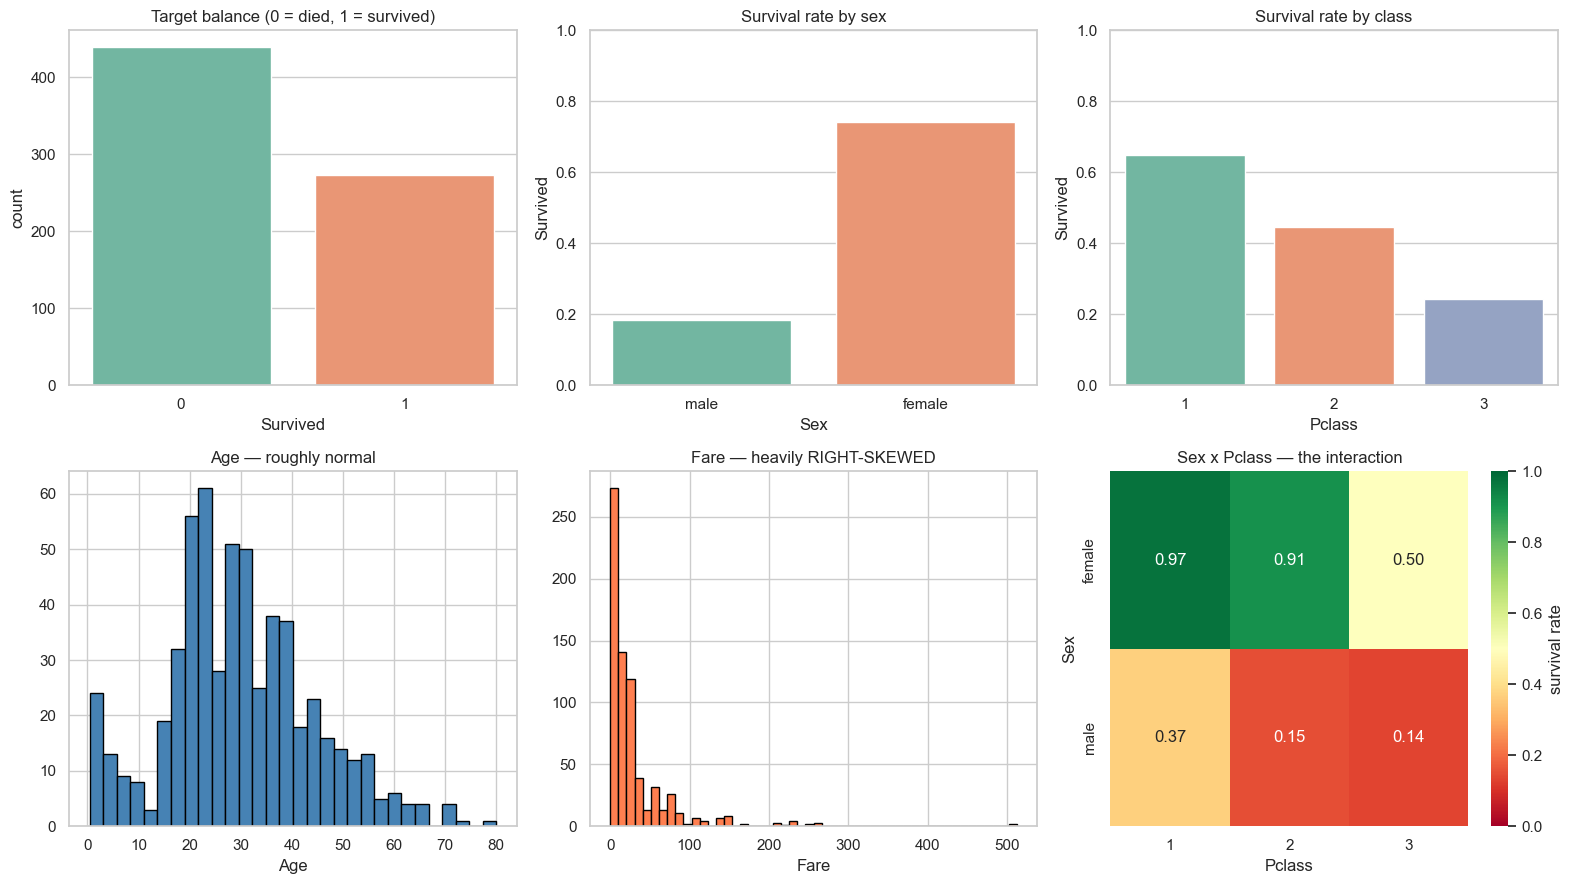

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=train, x="Survived", hue="Survived", legend=False,
              palette="Set2", ax=ax[0,0])
ax[0,0].set_title("Target balance (0 = died, 1 = survived)")

sns.barplot(data=train, x="Sex", y="Survived", hue="Sex", legend=False,
            palette="Set2", errorbar=None, ax=ax[0,1])
ax[0,1].set_title("Survival rate by sex"); ax[0,1].set_ylim(0,1)

sns.barplot(data=train, x="Pclass", y="Survived", hue="Pclass", legend=False,
            palette="Set2", errorbar=None, ax=ax[0,2])
ax[0,2].set_title("Survival rate by class"); ax[0,2].set_ylim(0,1)

ax[1,0].hist(train.Age.dropna(), bins=30, color="steelblue", edgecolor="black")
ax[1,0].set_title("Age — roughly normal"); ax[1,0].set_xlabel("Age")

ax[1,1].hist(train.Fare, bins=50, color="coral", edgecolor="black")
ax[1,1].set_title("Fare — heavily RIGHT-SKEWED"); ax[1,1].set_xlabel("Fare")

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            ax=ax[1,2], cbar_kws={"label":"survival rate"})
ax[1,2].set_title("Sex x Pclass — the interaction")

plt.tight_layout(); plt.show()

### EDA conclusions → what to build next

1. **Sex dominates.** Also a sanity check — if the model doesn't rank it highly, something's broken.
2. **`Pclass` is ordered** (1 > 2 > 3) — keep the ordering, don't one-hot it.
3. **Sex × Pclass interact** → tree models, or a hand-built feature.
4. **Fare is right-skewed** → `log1p`.
5. **Cabin is 75% missing but informatively so** → `HasCabin`.
6. **`FamilySize`** captures a non-linear pattern.
7. **`Title`** gives a child/status signal with no gaps.

---
# Step 2 — Feature Engineering

**This is where the biggest gains come from.** On this dataset feature
engineering is worth about a point; swapping a tuned forest for a tuned
booster is worth well under one.

## Why a class instead of notebook cells

Two of the features below — group size and ticket prefix — are **fitted**
(and off by default; 2.1 explains why):
they need counts computed from the training data. That is exactly the kind of
thing that leaks if you compute it once over the whole file, and exactly why
it belongs inside the transformer's `fit` rather than in a notebook cell.

Production must transform data **exactly** the way training did. Hand-edited
cells can't be reproduced. So every transformation lives in a transformer that
slots into a `Pipeline` — which also means the imputer and scaler refit inside
every cross-validation fold, making leakage structurally impossible.

In [13]:
TITLE_MAP = {"Mlle":"Miss", "Ms":"Miss", "Mme":"Mrs",
             "Lady":"Rare","Countess":"Rare","Capt":"Rare","Col":"Rare",
             "Don":"Rare","Dona":"Rare","Dr":"Rare","Major":"Rare",
             "Rev":"Rare","Sir":"Rare","Jonkheer":"Rare"}


def ticket_prefix(ticket):
    """'STON/O2. 3101282' -> 'STONO2', '113803' -> 'NONE'.

    The prefix is a coarse proxy for the issuing office and route.
    """
    p = (ticket.astype(str).str.strip()
               .str.replace(r"[./]", "", regex=True)
               .str.split().str[0].str.upper())
    return p.where(~(p.str.isdigit() | p.eq("")), "NONE")


class TitanicFeatures(BaseEstimator, TransformerMixin):
    """Builds every engineered feature.

    `ticket_features` defaults to **False**. They are built, and 2.1 measures
    them head-to-head — but on the synthetic stand-in they do not clear the
    fold-to-fold noise, so the notebook takes its own advice and leaves them
    out. Pass `ticket_features=True` to switch them on, which is worth doing
    against the real Kaggle file where shared tickets carry real signal.

    Everything except the ticket block learns NOTHING from the data, so it is
    leak-proof by construction. The ticket block DOES learn two statistics —
    how many passengers share each ticket, and which prefixes are common
    enough to keep — so they are fitted in `fit`, which the Pipeline calls on
    the training fold only. Same guarantee, earned differently.
    """
    def __init__(self, ticket_features=False):
        self.ticket_features = ticket_features

    def fit(self, X, y=None):
        if self.ticket_features:
            tick = X["Ticket"].astype(str).str.strip()
            self.ticket_counts_ = tick.value_counts()
            pref = ticket_prefix(tick).value_counts()
            # collapse prefixes too rare to estimate a rate from
            self.prefixes_ = set(pref[pref >= 10].index) | {"NONE"}
        return self

    def transform(self, X):
        d = X.copy()

        # 1. Title from Name. Name is NEVER missing, unlike Age.
        d["Title"] = (d["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
                               .replace(TITLE_MAP).fillna("Rare"))
        d.loc[~d.Title.isin(["Mr","Mrs","Miss","Master"]), "Title"] = "Rare"

        # 2. Family structure — each part is weak, together they show structure
        d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
        d["IsAlone"] = (d.FamilySize == 1).astype(int)
        d["FamilyBand"] = pd.cut(d.FamilySize, bins=[0,1,4,20],
                                 labels=["Alone","Small","Large"]).astype(str)

        # 3. Missingness AS a feature
        d["HasCabin"] = d["Cabin"].notnull().astype(int)
        d["Deck"] = d["Cabin"].astype(str).str[0].replace("n", "Unknown")
        d["AgeMissing"] = d["Age"].isnull().astype(int)

        # 4. Tame the skew. log1p handles fares that are exactly 0.
        d["FarePerPerson"] = d["Fare"] / d["FamilySize"]
        d["FareLog"] = np.log1p(d["Fare"])
        d["FarePerPersonLog"] = np.log1p(d["FarePerPerson"])

        # 5. Explicit interaction — lets linear models compete with trees
        d["SexClass"] = d["Sex"] + "_" + d["Pclass"].astype(str)

        # 6. The Ticket column, mined instead of discarded. OFF by default —
        #    see 2.1 for the measurement that decided it.
        if self.ticket_features:
            tick = d["Ticket"].astype(str).str.strip()

            # GroupSize counts everyone on the SAME TICKET — nannies, servants,
            # friends, fiances. SibSp/Parch cannot see any of them, because
            # they only count blood relatives and spouses.
            grp = tick.map(self.ticket_counts_).fillna(1).astype(float)
            d["GroupSize"] = np.maximum(grp, d["FamilySize"])
            d["InGroup"] = (d["GroupSize"] > 1).astype(int)
            d["NonFamilyCompanions"] = (d["GroupSize"] - d["FamilySize"]).clip(lower=0)

            # Fare is charged PER TICKET, not per person. Dividing by the true
            # party size is a better wealth signal than dividing by FamilySize.
            d["FarePerTicketLog"] = np.log1p(d["Fare"] / d["GroupSize"])

            pref = ticket_prefix(tick)
            d["TicketPrefix"] = pref.where(pref.isin(self.prefixes_), "OTHER")

        # 7. Drop only AFTER mining. Deleting text columns first wastes them.
        return d.drop(columns=["Name","Ticket","Cabin","PassengerId"],
                      errors="ignore")


NUMERIC = ["Age","SibSp","Parch","FamilySize","FareLog","FarePerPersonLog",
           "HasCabin","IsAlone","AgeMissing"]
CATEGORICAL = ["Sex","Embarked","Title","FamilyBand","SexClass","Deck"]
ORDINAL = ["Pclass"]        # 1 < 2 < 3 is a real ordering — keep as a number

TICKET_NUMERIC = ["GroupSize","InGroup","NonFamilyCompanions","FarePerTicketLog"]
TICKET_CATEGORICAL = ["TicketPrefix"]


def build_preprocessor(scale=True, ticket_features=False):
    """Every statistic here is learned in `fit`, which the Pipeline calls on
    the TRAINING fold only. That is what prevents leakage."""
    numeric = NUMERIC + (TICKET_NUMERIC if ticket_features else [])
    categorical = CATEGORICAL + (TICKET_CATEGORICAL if ticket_features else [])
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          # handle_unknown avoids a crash on new categories
                          ("encode", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]),
         categorical),
        ("ord", Pipeline([("impute", SimpleImputer(strategy="most_frequent"))]),
         ORDINAL),
    ])


def build_pipeline(model, scale=True, ticket_features=False):
    """features -> preprocessing -> model, as ONE saveable object."""
    return Pipeline([("features", TitanicFeatures(ticket_features=ticket_features)),
                     ("prep", build_preprocessor(scale=scale,
                                                 ticket_features=ticket_features)),
                     ("model", model)])

print("TitanicFeatures and build_pipeline defined.")
print("ticket features: OFF by default (see 2.1 for why)")


TitanicFeatures and build_pipeline defined.
ticket features: OFF by default (see 2.1 for why)


### Do the new features actually carry signal?

In [14]:
eng = TitanicFeatures().fit_transform(X_train)      # defaults: no ticket block
new_cols = [c for c in eng.columns if c not in X_train.columns]
print(f"{X_train.shape[1]} raw columns -> {eng.shape[1]} columns")
print(f"\n{len(new_cols)} NEW features: {new_cols}\n")

check = eng.join(y_train)
for col in ["Title","FamilyBand","HasCabin","SexClass"]:
    print(f"--- {col} ---")
    print(check.groupby(col, observed=True)["Survived"]
               .agg(["mean","count"]).round(3).to_string())
    print()

# The opt-in ticket block, shown even though 2.1 votes it out by default.
eng_t = TitanicFeatures(ticket_features=True).fit(X_train).transform(X_train)
check_t = eng_t.join(y_train)
print(f"with ticket_features=True: {eng_t.shape[1]} columns "
      f"(+{eng_t.shape[1] - eng.shape[1]})\n")
for col in ["InGroup", "TicketPrefix"]:
    print(f"--- {col} ---")
    print(check_t.groupby(col, observed=True)["Survived"]
                 .agg(["mean","count"]).round(3).to_string())
    print()


11 raw columns -> 18 columns

11 NEW features: ['Title', 'FamilySize', 'IsAlone', 'FamilyBand', 'HasCabin', 'Deck', 'AgeMissing', 'FarePerPerson', 'FareLog', 'FarePerPersonLog', 'SexClass']

--- Title ---
         mean  count
Title               
Master  0.548     31
Miss    0.708    144
Mr      0.153    412
Mrs     0.785    107
Rare    0.389     18

--- FamilyBand ---
             mean  count
FamilyBand              
Alone       0.300    434
Large       0.160     50
Small       0.592    228

--- HasCabin ---
           mean  count
HasCabin              
0         0.292    552
1         0.700    160

--- SexClass ---
           mean  count
SexClass              
female_1  0.975     79
female_2  0.914     58
female_3  0.500    116
male_1    0.370     92
male_2    0.152     92
male_3    0.135    275

with ticket_features=True: 23 columns (+5)

--- InGroup ---
          mean  count
InGroup              
0        0.268    384
1        0.518    328

--- TicketPrefix ---
               mean 

In [15]:
# what the model actually receives
demo = build_pipeline(LogisticRegression(max_iter=1000)).fit(X_train, y_train)
mat = demo.named_steps["prep"].transform(
        demo.named_steps["features"].transform(X_train))
print(f"raw DataFrame : {X_train.shape}   (text, blanks, skew)")
print(f"model matrix  : {mat.shape}   (all numeric, no blanks, scaled)")

raw DataFrame : (712, 11)   (text, blanks, skew)
model matrix  : (712, 38)   (all numeric, no blanks, scaled)


## 2.1 Do the ticket features earn their place?

A feature is not free just because it is clever. Same models, same folds, the
only difference is `ticket_features` on or off — that is the whole experiment.

The bar is not "delta > 0". The bar is **delta bigger than the fold-to-fold
variation**, which is the same standard we hold every other result to.

On the synthetic stand-in they fail that bar, so `ticket_features` defaults to
`False` and everything after this point runs without them. Acting on the
measurement is the whole point of taking it — an experiment you overrule
whenever you dislike the answer was never an experiment.

In [16]:
ticket_trials = [
    ("LogisticRegression",     lambda: LogisticRegression(max_iter=2000, random_state=42), True),
    ("RandomForest (depth 6)", lambda: RandomForestClassifier(n_estimators=300, max_depth=6,
                                       min_samples_leaf=4, random_state=42), False),
    ("GradientBoosting",       lambda: GradientBoostingClassifier(random_state=42), False),
]

cv_ticket = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'model':<26}{'without':>10}{'with':>10}{'delta':>10}{'fold std':>10}")
print("-" * 66)

tdeltas, tstds = [], []
for label, make, sc in ticket_trials:
    a = cross_val_score(build_pipeline(make(), scale=sc, ticket_features=False),
                        X_train, y_train, cv=cv_ticket, scoring=METRIC)
    b = cross_val_score(build_pipeline(make(), scale=sc, ticket_features=True),
                        X_train, y_train, cv=cv_ticket, scoring=METRIC)
    tdeltas.append(b.mean() - a.mean())
    tstds.append(max(a.std(), b.std()))
    print(f"{label:<26}{a.mean():>10.4f}{b.mean():>10.4f}"
          f"{b.mean()-a.mean():>+10.4f}{tstds[-1]:>10.4f}")

ticket_delta = float(np.mean(tdeltas))
noise = float(np.mean(tstds))
print(f"\naverage delta {ticket_delta:+.4f}    typical fold-to-fold std {noise:.4f}")

if ticket_delta > noise:
    print(">>> KEEP. The gain clears the fold-to-fold noise, which is rare")
    print(">>> for a single feature block on 712 rows.")
elif ticket_delta > 0:
    print(">>> Positive but INSIDE the noise. The honest verdict is 'no")
    print(">>> measurable harm, no proven gain'. Keeping the features on a")
    print(">>> delta this size is a judgement call, not a result — and saying")
    print(">>> so out loud is the difference between analysis and wishful")
    print(">>> thinking. The default stays OFF: an unproven feature is cost")
    print(">>> without demonstrated benefit. Flip it on for the real data.")
else:
    print(">>> They cost more than they pay HERE. Two extra one-hot columns")
    print(">>> and four numerics give a model more to overfit; if the Ticket")
    print(">>> column carries little signal, that is a net loss.")
    print(">>> On the real Kaggle file shared tickets are strongly informative,")
    print(">>> so this is a good cell to re-run with train.csv in place.")
print(f"\nDefault in build_pipeline: ticket_features=False. "
      f"This run measured {ticket_delta:+.4f}.")

model                        without      with     delta  fold std
------------------------------------------------------------------


LogisticRegression            0.8245    0.8273   +0.0028    0.0246


RandomForest (depth 6)        0.8203    0.8132   -0.0070    0.0183


GradientBoosting              0.8146    0.8217   +0.0071    0.0207

average delta +0.0010    typical fold-to-fold std 0.0212
>>> Positive but INSIDE the noise. The honest verdict is 'no
>>> measurable harm, no proven gain'. Keeping the features on a
>>> delta this size is a judgement call, not a result — and saying
>>> so out loud is the difference between analysis and wishful
>>> thinking. The default stays OFF: an unproven feature is cost
>>> without demonstrated benefit. Flip it on for the real data.

Default in build_pipeline: ticket_features=False. This run measured +0.0010.


---
# Step 3 — Compare Models

**Strategy: breadth first, depth later.** Don't spend three hours tuning the
first model. Spend twenty minutes comparing eight (more, if XGBoost or
LightGBM are installed), then tune the best.

Three things beginners skip, all of which we do here:
1. Establish a **baseline** before anything else
2. Read the **standard deviation**, not just the mean
3. Check the **train-vs-CV gap** to diagnose overfitting

Everything here is scored with `METRIC`. 3.1b then re-ranks the same models
under three different metrics, which is where it gets interesting.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Distance-based models need scaling. Trees split on thresholds, so they don't.
NEEDS_SCALING = {"KNN","SVM","LogisticRegression","NaiveBayes"}

models = {
    "Baseline":           DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "NaiveBayes":         GaussianNB(),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
}

# Bolt on whichever boosting libraries are installed.
for _name, _cls in BOOSTERS.items():
    models[_name] = (_cls(random_state=42, n_jobs=-1, eval_metric="logloss")
                     if _name == "XGBoost" else
                     _cls(random_state=42, n_jobs=-1, verbose=-1))

rows = []
print(f"scoring: {METRIC}\n")
print(f"{'model':<20}{'CV mean':>10}{'std':>9}{'train':>9}{'gap':>9}")
print("-" * 57)

for name, m in models.items():
    pipe = build_pipeline(m, scale=(name in NEEDS_SCALING))
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=METRIC)
    pipe.fit(X_train, y_train)
    tr = SCORER(pipe, X_train, y_train)   # same metric, so the gap is meaningful
    gap = tr - scores.mean()
    rows.append({"model":name, "cv_mean":scores.mean(), "cv_std":scores.std(),
                 "train":tr, "gap":gap})
    flag = "  <-- OVERFIT" if gap > 0.10 else ""
    print(f"{name:<20}{scores.mean():>10.4f}{scores.std():>9.4f}"
          f"{tr:>9.4f}{gap:>9.4f}{flag}")

res = pd.DataFrame(rows).sort_values("cv_mean", ascending=False)

scoring: accuracy

model                  CV mean      std    train      gap
---------------------------------------------------------
Baseline                0.6166   0.0027   0.6166  -0.0000


LogisticRegression      0.8245   0.0206   0.8525   0.0281
NaiveBayes              0.7922   0.0427   0.8062   0.0140


DecisionTree            0.7837   0.0236   0.9874   0.2036  <-- OVERFIT


KNN                     0.8118   0.0145   0.8624   0.0505
SVM                     0.8216   0.0127   0.8427   0.0210


RandomForest            0.8132   0.0159   0.9874   0.1742  <-- OVERFIT


GradientBoosting        0.8146   0.0187   0.9242   0.1096  <-- OVERFIT


XGBoost                 0.8203   0.0220   0.9803   0.1601  <-- OVERFIT


## 3.1 How to read that table

In [18]:
best, second = res.iloc[0], res.iloc[1]
diff = best.cv_mean - second.cv_mean
print(f"top    : {best.model} {best.cv_mean:.4f} (std {best.cv_std:.4f})")
print(f"runner : {second.model} {second.cv_mean:.4f} (std {second.cv_std:.4f})")
print(f"gap    : {diff:.4f}")

if diff < max(best.cv_std, second.cv_std):
    print("\n>>> The gap is SMALLER than the fold-to-fold variation.")
    print(">>> That difference is NOT meaningful yet. Calling a winner")
    print(">>> on it would be overclaiming.")

top    : LogisticRegression 0.8245 (std 0.0206)
runner : SVM 0.8216 (std 0.0127)
gap    : 0.0028

>>> The gap is SMALLER than the fold-to-fold variation.
>>> That difference is NOT meaningful yet. Calling a winner
>>> on it would be overclaiming.


## 3.1b Does the metric change the winner?

Step 3.1 ranked the models on `METRIC`. But "best model" is not a property of
a model — it is a property of a model **and** a metric. Ranking the identical
models, on the identical folds, under three different metrics:

- **accuracy** — every mistake costs the same, and true negatives count
- **F1** — the harmonic mean of precision and recall; true negatives are
  ignored entirely, so it cares only about the positive class
- **ROC AUC** — threshold-free ranking quality: given one survivor and one
  casualty, how often does the model score the survivor higher?

A model that hedges near 0.5 can have excellent AUC and mediocre accuracy.
The two are asking different questions.

In [19]:
multi = []
for name, m in models.items():
    if name == "Baseline":
        continue
    pipe = build_pipeline(m, scale=(name in NEEDS_SCALING))
    r = cross_validate(pipe, X_train, y_train, cv=cv, n_jobs=-1,
                       scoring=["accuracy", "f1", "roc_auc"])
    multi.append({"model": name, "accuracy": r["test_accuracy"].mean(),
                  "f1": r["test_f1"].mean(), "roc_auc": r["test_roc_auc"].mean()})

mm = pd.DataFrame(multi).set_index("model").sort_values(METRIC, ascending=False)
display(mm.round(4))

winners = {c: mm[c].idxmax() for c in mm.columns}
for c, w in winners.items():
    print(f"best on {c:<9}: {w:<20} {mm.loc[w, c]:.4f}")

if len(set(winners.values())) == 1:
    print("\n>>> The same model tops all three. Here the metric does not change")
    print(">>> the decision — but do not generalise from that. On imbalanced")
    print(">>> data (fraud, disease screening) it almost always does.")
else:
    print("\n>>> DIFFERENT metrics crown DIFFERENT models.")
    print(">>> There is no best model in the abstract, only best-for-a-metric.")
    print(">>> So the order is: work out what a false positive and a false")
    print(">>> negative each COST, pick the metric that reflects that, and")
    print(">>> only THEN rank. Picking the metric after seeing the rankings")
    print(">>> is just p-hacking with extra steps.")

print(f"\nRe-run everything from here with METRIC = 'f1' or 'roc_auc'")
print("in the setup cell to carry a different choice through Step 4.")

,accuracy,f1,roc_auc
model,,,
LogisticRegression,0.8245,0.7613,0.8816
SVM,0.8216,0.7533,0.8635
XGBoost,0.8203,0.7523,0.8837
GradientBoosting,0.8146,0.7439,0.8917
RandomForest,0.8132,0.7503,0.8717
KNN,0.8118,0.7439,0.8397
NaiveBayes,0.7922,0.7466,0.8509
DecisionTree,0.7837,0.7193,0.7705


best on accuracy : LogisticRegression   0.8245
best on f1       : LogisticRegression   0.7613
best on roc_auc  : GradientBoosting     0.8917

>>> DIFFERENT metrics crown DIFFERENT models.
>>> There is no best model in the abstract, only best-for-a-metric.
>>> So the order is: work out what a false positive and a false
>>> negative each COST, pick the metric that reflects that, and
>>> only THEN rank. Picking the metric after seeing the rankings
>>> is just p-hacking with extra steps.

Re-run everything from here with METRIC = 'f1' or 'roc_auc'
in the setup cell to carry a different choice through Step 4.


## 3.2 Overfitting diagnosis

**The gap is the signal, not the raw training score.** A decision tree scoring
1.000 on training hasn't learned — it has memorised.

In [20]:
for _, r in res.iterrows():
    if r.model == "Baseline":
        continue
    v = ("severe overfit — memorising rows" if r.gap > 0.15 else
         "overfitting — worth regularising" if r.gap > 0.07 else
         "healthy, could be more complex"   if r.gap < 0.02 else "healthy")
    print(f"{r.model:<20} gap {r.gap:>7.3f}   {v}")

dt = res.loc[res.model=="DecisionTree"].iloc[0]
rf = res.loc[res.model=="RandomForest"].iloc[0]
print(f"\nOne DecisionTree scores {dt.cv_mean:.3f}. Averaging 200 of them")
print(f"(RandomForest) scores {rf.cv_mean:.3f}. Their individual mistakes are")
print("random and point in different directions, so they cancel out.")
print("That is BAGGING, and it is the whole idea behind random forests.")

LogisticRegression   gap   0.028   healthy
SVM                  gap   0.021   healthy
XGBoost              gap   0.160   severe overfit — memorising rows
GradientBoosting     gap   0.110   overfitting — worth regularising
RandomForest         gap   0.174   severe overfit — memorising rows
KNN                  gap   0.051   healthy
NaiveBayes           gap   0.014   healthy, could be more complex
DecisionTree         gap   0.204   severe overfit — memorising rows

One DecisionTree scores 0.784. Averaging 200 of them
(RandomForest) scores 0.813. Their individual mistakes are
random and point in different directions, so they cancel out.
That is BAGGING, and it is the whole idea behind random forests.


## 3.3 Does feature engineering earn its keep?

Watch what happens to the **unregularised** forest. This is the most
counter-intuitive result in the project.

In [21]:
raw_prep = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),
                      ("s",StandardScaler())]),
     ["Age","SibSp","Parch","Fare","Pclass"]),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                      ("e",OneHotEncoder(handle_unknown="ignore",
                                         sparse_output=False))]),
     ["Sex","Embarked"]),
])

trials = [
    ("LogisticRegression",      lambda: LogisticRegression(max_iter=2000, random_state=42), True),
    ("RandomForest (depth 6)",  lambda: RandomForestClassifier(n_estimators=300, max_depth=6,
                                        min_samples_leaf=4, random_state=42), False),
    ("RandomForest (no limit)", lambda: RandomForestClassifier(n_estimators=300,
                                        random_state=42), False),
]

print(f"{'model':<26}{'raw':>9}{'engineered':>13}{'delta':>10}")
print("-" * 58)
deltas = {}
for label, make, sc in trials:
    a = cross_val_score(Pipeline([("prep",raw_prep),("model",make())]),
                        X_train, y_train, cv=cv, scoring=METRIC).mean()
    b = cross_val_score(build_pipeline(make(), scale=sc),
                        X_train, y_train, cv=cv, scoring=METRIC).mean()
    deltas[label] = b - a
    print(f"{label:<26}{a:>9.4f}{b:>13.4f}{b-a:>+10.4f}")

# Interpret whatever this run actually produced, rather than assuming.
reg = np.mean([deltas["LogisticRegression"], deltas["RandomForest (depth 6)"]])
unreg = deltas["RandomForest (no limit)"]
print()
print(f"avg delta for the REGULARISED models : {reg:+.4f}")
print(f"delta for the UNREGULARISED forest   : {unreg:+.4f}")

if unreg < reg - 0.003:
    print()
    print(">>> The unregularised forest gained LESS from the extra features,")
    print(">>> or lost ground. Going from 10 columns to 36 handed it more")
    print(">>> noise to memorise, and nothing was stopping it.")
elif unreg > reg + 0.003:
    print()
    print(">>> This run the unregularised forest gained MORE. That happens:")
    print(">>> with 891 rows the fold-to-fold noise is around 0.02, so a")
    print(">>> delta of a few thousandths is not a stable finding either way.")
    print(">>> Re-run with a different random_state and it may well flip.")
else:
    print()
    print(">>> All three gained about the same amount here.")

print()
print("EITHER WAY, the transferable point stands: extra features are not")
print("free. They only help a model constrained enough to handle them, and")
print("a delta smaller than the fold-to-fold std is not yet a real result.")

model                           raw   engineered     delta
----------------------------------------------------------


LogisticRegression           0.7963       0.8245   +0.0281


RandomForest (depth 6)       0.8202       0.8203   +0.0001


RandomForest (no limit)      0.7977       0.8118   +0.0141

avg delta for the REGULARISED models : +0.0141
delta for the UNREGULARISED forest   : +0.0141

>>> All three gained about the same amount here.

EITHER WAY, the transferable point stands: extra features are not
free. They only help a model constrained enough to handle them, and
a delta smaller than the fold-to-fold std is not yet a real result.


### The lesson hiding in that table

Two things worth taking away, and the cell above tells you which one this
particular run demonstrated.

**1. Extra features are not free.** Going from 10 columns to 36 gives a model
more signal *and* more noise. A regularised model can exploit the signal and
ignore the noise; an unlimited-depth forest has nothing stopping it memorising
the noise. So *"add more features"* is not good advice on its own — the correct
version is **add better features, and control model complexity to match.**

**2. These deltas are small, and small deltas are unreliable.** With 891 rows
the fold-to-fold standard deviation is around 0.02, so a delta of ±0.005 is
well inside the noise. Re-run with a different `random_state` and the ranking
can flip.

This is the same experiment as 2.1, run one level up: there we asked whether
one *block* of features earned its place, here whether the *whole* engineered
set does. Same design, same standard of evidence.

That second point is the more important discipline. It is the same lesson as
Step 3.1: **a difference smaller than the variation is not yet a finding.**
The honest way to settle it would be repeated cross-validation across many
seeds, exactly as we do for the held-out score in Step 4.5.

## 3.4 What did the model learn? (also a leakage check)

In [22]:
rf_pipe = build_pipeline(RandomForestClassifier(n_estimators=300, max_depth=6,
                         min_samples_leaf=4, random_state=42), scale=False)
rf_pipe.fit(X_train, y_train)

names = rf_pipe.named_steps["prep"].get_feature_names_out()
builtin = pd.Series(rf_pipe.named_steps["model"].feature_importances_,
                    index=names).sort_values(ascending=False)
print("Built-in importance (top 10):")
print(builtin.head(10).round(4).to_string())

perm = permutation_importance(rf_pipe, X_hold, y_hold, n_repeats=15,
                              random_state=42, scoring="accuracy")
perm_s = pd.Series(perm.importances_mean,
                   index=X_hold.columns).sort_values(ascending=False)
print("\nPermutation importance on raw columns (top 8):")
print(perm_s.head(8).round(4).to_string())

Built-in importance (top 10):
cat__Title_Mr             0.1539
cat__Sex_female           0.1233
cat__Sex_male             0.1214
num__FarePerPersonLog     0.0658
num__FareLog              0.0580
cat__SexClass_female_1    0.0521
num__Age                  0.0458
cat__SexClass_male_3      0.0409
ord__Pclass               0.0371
cat__SexClass_female_2    0.0317



Permutation importance on raw columns (top 8):
Sex         0.1102
Name        0.0451
SibSp       0.0354
Age         0.0294
Pclass      0.0235
Parch       0.0123
Fare        0.0034
Embarked    0.0034


### Why the two lists disagree — and why it matters

They answer **different questions**:

- Built-in asks: *"how much did the trees USE this column?"*
- Permutation asks: *"how much accuracy do I LOSE without it?"*

On permutation importance almost everything sits near zero — even `Pclass` and
`Age`, which the EDA proved matter. Not because they're useless, but because
they're **redundant**: shuffle `Pclass` and the model still reads class from
`Fare` and `SexClass`. Only `Sex` is irreplaceable.

**Low permutation importance means "not uniquely needed", not "useless."**
Never drop correlated features on that evidence alone.

**Leakage check:** nothing meaningless (`PassengerId`, `Ticket`) is doing real
work, and `Sex` leads — matching the EDA. If an ID column had topped this list,
we'd stop and debug.

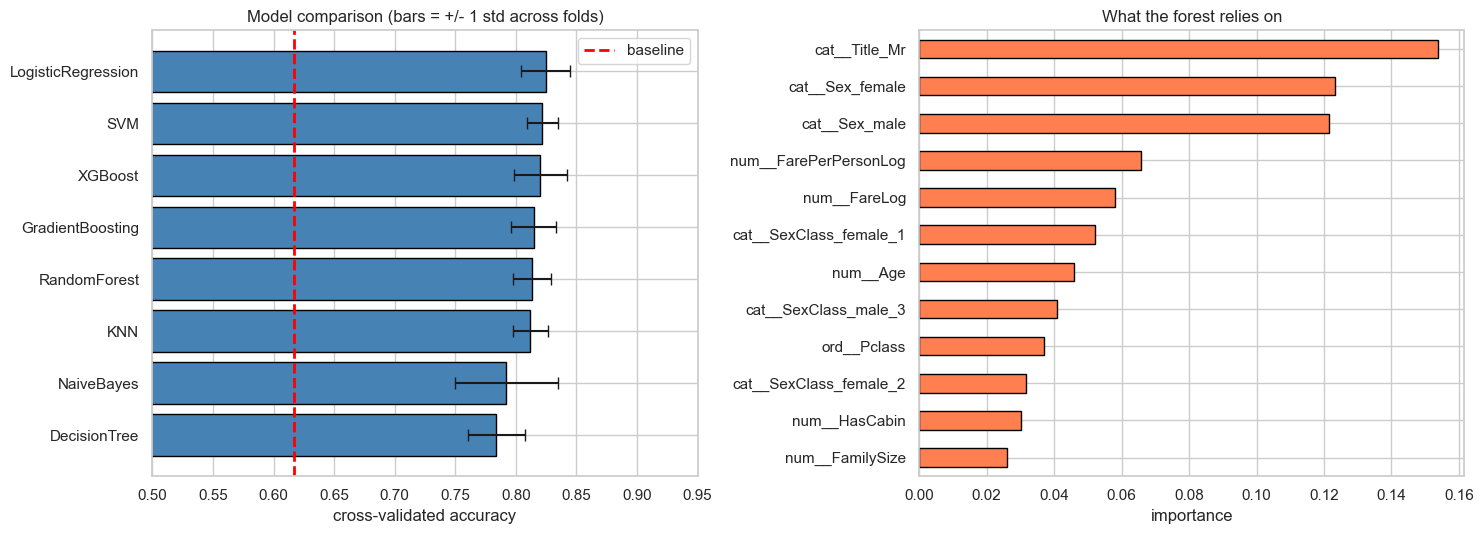

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
p = res[res.model != "Baseline"].sort_values("cv_mean")
ax[0].barh(p.model, p.cv_mean, xerr=p.cv_std, color="steelblue",
           edgecolor="black", capsize=4)
ax[0].axvline(res.loc[res.model=="Baseline","cv_mean"].iloc[0], color="red",
              ls="--", lw=2, label="baseline")
ax[0].set_xlim(0.5, 0.95); ax[0].legend()
ax[0].set_title("Model comparison (bars = +/- 1 std across folds)")
ax[0].set_xlabel("cross-validated accuracy")

builtin.head(12).sort_values().plot(kind="barh", ax=ax[1], color="coral",
                                    edgecolor="black")
ax[1].set_title("What the forest relies on"); ax[1].set_xlabel("importance")
plt.tight_layout(); plt.show()

### Shortlist

**"Best untuned" is not "best after tuning."** Carrying three models forward
for three different reasons:

- **LogisticRegression** — leads now, already healthy, fully interpretable
- **RandomForest** — overfitting badly, so it has the *most* to gain from regularisation
- **GradientBoosting** — same, plus it usually wins on tabular data once the learning rate comes down
- **XGBoost / LightGBM** — added automatically if installed; they are the same
  idea as GradientBoosting with better regularisation and much faster fits

A model that overfits isn't a bad model. It's an **untuned** model.

---
# Step 4 — Tune, then Evaluate ONCE

## 4.1 Why random search beats grid search

A grid of 5 values across 5 hyperparameters is 5⁵ = 3,125 combinations × 5
folds = **15,625 fits**. Random search with 40 iterations does 200 and usually
lands just as well.

**Why:** most hyperparameters barely matter. Grid search burns its budget
re-testing values of unimportant parameters; random search spends it exploring
the important ones. It can also sample **continuous** ranges, which a grid can't.

> Note the `model__` prefix below. Inside a Pipeline you address a step's
> parameters as `stepname__paramname`. Forgetting this is the most common
> tuning error.

The search optimises `METRIC`, so switching that at the top genuinely
changes which hyperparameters win — not just which number gets printed.

**This cell takes several minutes.**

In [24]:
SEARCHES = {
    "LogisticRegression": (
        LogisticRegression(max_iter=4000, random_state=42), True,
        {"model__C": loguniform(1e-3, 1e2)},          # C is INVERSE regularisation
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42, n_jobs=-1), False,
        {"model__n_estimators":      randint(200, 700),
         "model__max_depth":         randint(3, 14),   # main overfit control
         "model__min_samples_leaf":  randint(1, 12),
         "model__min_samples_split": randint(2, 20),
         "model__max_features":      ["sqrt","log2",0.4,0.6]},
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42), False,
        # learning_rate and n_estimators trade off: halve the rate, double the trees
        {"model__learning_rate":    loguniform(0.01, 0.3),
         "model__n_estimators":     randint(100, 500),
         "model__max_depth":        randint(2, 6),
         "model__min_samples_leaf": randint(1, 12),
         "model__subsample":        uniform(0.7, 0.3)},
    ),
}

# Same treatment for whichever boosting library is installed. Note the extra
# regularisation knobs - that is the main thing these buy you over sklearn's
# GradientBoosting, along with much faster fits.
if "XGBoost" in BOOSTERS:
    SEARCHES["XGBoost"] = (
        BOOSTERS["XGBoost"](random_state=42, n_jobs=-1, eval_metric="logloss"), False,
        {"model__learning_rate":    loguniform(0.01, 0.3),
         "model__n_estimators":     randint(100, 600),
         "model__max_depth":        randint(2, 8),
         "model__subsample":        uniform(0.6, 0.4),
         "model__colsample_bytree": uniform(0.6, 0.4),
         "model__min_child_weight": randint(1, 10),
         "model__reg_lambda":       loguniform(1e-2, 1e2)},
    )
if "LightGBM" in BOOSTERS:
    SEARCHES["LightGBM"] = (
        BOOSTERS["LightGBM"](random_state=42, n_jobs=-1, verbose=-1), False,
        {"model__learning_rate":    loguniform(0.01, 0.3),
         "model__n_estimators":     randint(100, 600),
         "model__num_leaves":       randint(8, 64),
         "model__min_child_samples": randint(5, 40),
         "model__subsample":        uniform(0.6, 0.4),
         "model__colsample_bytree": uniform(0.6, 0.4),
         "model__reg_lambda":       loguniform(1e-2, 1e2)},
    )

print("tuning:", ", ".join(SEARCHES), f"   (scoring: {METRIC})")

tuned, summary = {}, []
for name, (model, scale, space) in SEARCHES.items():
    pipe = build_pipeline(model, scale=scale)
    before = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=METRIC).mean()
    pipe.fit(X_train, y_train)
    before_tr = SCORER(pipe, X_train, y_train)

    search = RandomizedSearchCV(pipe, space, n_iter=40, cv=cv,
                                scoring=METRIC, n_jobs=-1, random_state=42)
    search.fit(X_train, y_train)

    tuned[name] = search.best_estimator_
    after = search.best_score_
    after_tr = SCORER(search.best_estimator_, X_train, y_train)

    print(f"\n--- {name} ---")
    print(f"  before: CV {before:.4f}  train {before_tr:.4f}  gap {before_tr-before:+.4f}")
    print(f"  after : CV {after:.4f}  train {after_tr:.4f}  gap {after_tr-after:+.4f}")
    print(f"  best params:")
    for k, v in sorted(search.best_params_.items()):
        print(f"      {k.replace('model__',''):<20} "
              f"{v:.4f}" if isinstance(v, float) else
              f"      {k.replace('model__',''):<20} {v}")
    if (before_tr-before) > 0.10 and (after_tr-after) < (before_tr-before):
        print("  >>> training score FELL, CV ROSE, gap closed.")
        print("      That is regularisation working exactly as intended.")

    summary.append({"model":name, "cv_before":before, "cv_after":after,
                    "train_after":after_tr, "gap_after":after_tr-after})

tuning: LogisticRegression, RandomForest, GradientBoosting, XGBoost    (scoring: accuracy)



--- LogisticRegression ---
  before: CV 0.8245  train 0.8525  gap +0.0281
  after : CV 0.8273  train 0.8455  gap +0.0182
  best params:
      C                    0.4205



--- RandomForest ---
  before: CV 0.8146  train 0.9874  gap +0.1728
  after : CV 0.8343  train 0.9059  gap +0.0716
  best params:
      max_depth            9
      max_features         0.4000
      min_samples_leaf     3
      min_samples_split    3
      n_estimators         369
  >>> training score FELL, CV ROSE, gap closed.
      That is regularisation working exactly as intended.



--- GradientBoosting ---
  before: CV 0.8146  train 0.9242  gap +0.1096
  after : CV 0.8385  train 0.8989  gap +0.0604
  best params:
      learning_rate        0.0568
      max_depth            2
      min_samples_leaf     5
      n_estimators         324
      subsample            0.7360
  >>> training score FELL, CV ROSE, gap closed.
      That is regularisation working exactly as intended.



--- XGBoost ---
  before: CV 0.8203  train 0.9803  gap +0.1601
  after : CV 0.8357  train 0.9129  gap +0.0772
  best params:
      colsample_bytree     0.9758
      learning_rate        0.2098
      max_depth            7
      min_child_weight     8
      n_estimators         561
      reg_lambda           0.0608
      subsample            0.6181
  >>> training score FELL, CV ROSE, gap closed.
      That is regularisation working exactly as intended.


### What just happened

The training score went **down** while cross-validation went **up**. That
sounds backwards but it's the entire point: we didn't make the model better at
the training data, we made it **worse at memorising** — which is what let it
generalise.

If you remember one thing about overfitting, make it this.

## 4.2 Did the search hit the edge of its range?

If the best value sits at a boundary you searched, the true optimum may lie
beyond it — widen and search again.

In [25]:
d = tuned["RandomForest"].named_steps["model"].max_depth
lr = tuned["GradientBoosting"].named_steps["model"].learning_rate
print(f"RF max_depth searched 3-13, best = {d}"
      f"   {'<-- AT EDGE, widen' if d in (3,13) else 'OK, interior'}")
print(f"GB learning_rate searched 0.01-0.3, best = {lr:.4f}"
      f"   {'<-- near edge' if lr < 0.015 or lr > 0.28 else 'OK, interior'}")

# Same check for any booster that joined the search.
for _b in ("XGBoost", "LightGBM"):
    if _b in tuned:
        m = tuned[_b].named_steps["model"]
        print(f"{_b} learning_rate searched 0.01-0.3, best = {m.learning_rate:.4f}"
              f"   {'<-- near edge' if m.learning_rate < 0.015 or m.learning_rate > 0.28 else 'OK, interior'}")


RF max_depth searched 3-13, best = 9   OK, interior
GB learning_rate searched 0.01-0.3, best = 0.0568   OK, interior
XGBoost learning_rate searched 0.01-0.3, best = 0.2098   OK, interior


## 4.3 Ensembling

Ensembles work best when members make **different** mistakes — which is why we
picked varied model types earlier. `voting="soft"` averages probabilities,
usually better than a hard majority vote.

In [26]:
ensemble = VotingClassifier([(n.lower(), m) for n, m in tuned.items()],
                            voting="soft")
ens_cv = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring=METRIC).mean()
print(f"soft-voting ensemble CV ({METRIC}): {ens_cv:.4f}")

summary.append({"model":"Ensemble", "cv_before":np.nan, "cv_after":ens_cv,
                "train_after":np.nan, "gap_after":np.nan})
sm = pd.DataFrame(summary).sort_values("cv_after", ascending=False)
display(sm.round(4))

soft-voting ensemble CV (accuracy): 0.8343


,model,cv_before,cv_after,train_after,gap_after
2,GradientBoosting,0.8146,0.8385,0.8989,0.0604
3,XGBoost,0.8203,0.8357,0.9129,0.0772
1,RandomForest,0.8146,0.8343,0.9059,0.0716
4,Ensemble,NaN,0.8343,NaN,NaN
0,LogisticRegression,0.8245,0.8273,0.8455,0.0182


## 4.4 The final evaluation — held-out data, used ONCE

This is the moment we touch the held-out fifth. **Once.** The instant you look
at this number, adjust the model, and look again, it stops being honest.

In [27]:
winner_name = sm.iloc[0]["model"]
winner_cv = sm.iloc[0]["cv_after"]
winner = ensemble if winner_name == "Ensemble" else tuned[winner_name]

winner.fit(X_train, y_train)
y_pred = winner.predict(X_hold)
y_prob = winner.predict_proba(X_hold)[:, 1]

acc  = accuracy_score(y_hold, y_pred)
prec = precision_score(y_hold, y_pred)
rec  = recall_score(y_hold, y_pred)
f1   = f1_score(y_hold, y_pred)
auc  = roc_auc_score(y_hold, y_prob)
hold_metric = SCORER(winner, X_hold, y_hold)   # the metric we SELECTED on
tn, fp, fn, tp = confusion_matrix(y_hold, y_pred).ravel()

print(f"Winner: {winner_name}   selected on {METRIC}: CV {winner_cv:.4f} "
      f"-> held-out {hold_metric:.4f}\n")
print("Confusion matrix:")
print("                      PREDICTED")
print("                   died   survived")
print(f"  ACTUAL died     {tn:5d}   {fp:8d}")
print(f"         survived {fn:5d}   {tp:8d}")
print(f"\n  FP = {fp}  said survived, actually died  (Type I error)")
print(f"  FN = {fn}  said died, actually survived  (Type II error)")
print(f"\n  Accuracy  {acc:.4f}   of everything, how much was right")
print(f"  Precision {prec:.4f}   when I said 'survived', was I right")
print(f"  Recall    {rec:.4f}   of real survivors, how many I caught")
print(f"  F1        {f1:.4f}   the two above, balanced")
print(f"  ROC AUC   {auc:.4f}   ranking ability (0.5 = coin flip)")
print(f"\n  All five are reported whatever METRIC you selected on. Report the")
print(f"  metric you OPTIMISED ({METRIC}) plus the ones your audience needs.")

Winner: GradientBoosting   selected on accuracy: CV 0.8385 -> held-out 0.7989

Confusion matrix:
                      PREDICTED
                   died   survived
  ACTUAL died        96         14
         survived    22         47

  FP = 14  said survived, actually died  (Type I error)
  FN = 22  said died, actually survived  (Type II error)

  Accuracy  0.7989   of everything, how much was right
  Precision 0.7705   when I said 'survived', was I right
  Recall    0.6812   of real survivors, how many I caught
  F1        0.7231   the two above, balanced
  ROC AUC   0.8412   ranking ability (0.5 = coin flip)

  All five are reported whatever METRIC you selected on. Report the
  metric you OPTIMISED (accuracy) plus the ones your audience needs.


## 4.5 Reading that number honestly

Compare it to cross-validation. If there's a gap, **don't shrug** — diagnose it.

Three possible explanations:

- **Innocent 1 — selection bias.** You picked the winner by comparing dozens of
  configurations on CV scores. That selection is itself mild fitting, so the CV
  figure is optimistically biased. Some drop is always expected.
- **Innocent 2 — an unlucky split.** ~179 rows is small. One split can hand you
  an easy training set and a hard test set purely by chance.
- **Guilty — leakage, or a genuine failure to generalise.**

You cannot tell these apart from one number. **So measure the spread.**

In [28]:
n = len(y_hold)
se = np.sqrt(acc*(1-acc)/n)
lo, hi = acc - 1.96*se, acc + 1.96*se
print(f"CV said        : {winner_cv:.4f}   ({METRIC})")
print(f"Held-out says  : {hold_metric:.4f}   ({METRIC})")
print(f"Difference     : {winner_cv-hold_metric:+.4f}")

# The interval below is for ACCURACY specifically - the binomial standard
# error assumes each row is a right-or-wrong Bernoulli trial, which is true
# of accuracy and not of F1 or AUC.
print(f"\nn = {n}. One extra mistake moves accuracy by {1/n:.4f}.")
print(f"held-out accuracy {acc:.3f}, 95% CI [{lo:.3f}, {hi:.3f}]")

if METRIC == "accuracy":
    print("INSIDE the interval" if lo <= winner_cv <= hi else
          ">>> OUTSIDE the interval. Investigate before reporting.")
else:
    print(f"\n>>> METRIC is '{METRIC}', so that interval does not apply to it.")
    print(">>> For F1 or AUC the honest move is the empirical spread measured")
    print(">>> in the next cell, not a closed-form standard error.")


CV said        : 0.8385   (accuracy)
Held-out says  : 0.7989   (accuracy)
Difference     : +0.0396

n = 179. One extra mistake moves accuracy by 0.0056.
held-out accuracy 0.799, 95% CI [0.740, 0.858]
INSIDE the interval


### Measuring split variance

Refitting the winning configuration across 12 different random splits. If the
spread is wide, **no single split can be trusted.**

In [29]:
hold_scores, acc_scores = [], []
for seed in range(12):
    Xa, Xb, ya, yb = train_test_split(X_all, y_all, test_size=0.2,
                                      random_state=seed, stratify=y_all)
    m = clone(winner).fit(Xa, ya)
    hold_scores.append(SCORER(m, Xb, yb))       # the metric we selected on
    acc_scores.append(m.score(Xb, yb))          # accuracy, for reporting

hs = np.array(hold_scores)
accs = np.array(acc_scores)
print(f"held-out {METRIC} over 12 splits:")
print(f"    mean {hs.mean():.4f}   std {hs.std():.4f}")
print(f"    min  {hs.min():.4f}   max {hs.max():.4f}   range {np.ptp(hs):.4f}")
print(f"\nour single split (seed 42) gave {hold_metric:.4f}")
print(f"-> roughly the {(hs < hold_metric).mean()*100:.0f}th percentile of the 12")

if hold_metric < hs.mean() - hs.std():
    print("\n>>> VERDICT: seed 42 drew an UNLUCKY split.")
    print(">>> The held-out number is pessimistic, the CV number optimistic.")
    print(">>> The truth is the middle of that distribution.")
else:
    print("\n>>> VERDICT: the single split is representative.")

print(f"\nWHAT TO REPORT: not {hold_metric:.3f}, not {winner_cv:.3f}, but")
print(f"'{hs.mean():.3f} give or take {hs.std():.3f}' \u2014 and how you got it.")
if METRIC != "accuracy":
    print(f"\n(accuracy over the same 12 splits: {accs.mean():.3f} "
          f"+/- {accs.std():.3f} \u2014 for audiences who only understand accuracy.)")


held-out accuracy over 12 splits:
    mean 0.8436   std 0.0178
    min  0.8212   max 0.8883   range 0.0670

our single split (seed 42) gave 0.7989
-> roughly the 0th percentile of the 12

>>> VERDICT: seed 42 drew an UNLUCKY split.
>>> The held-out number is pessimistic, the CV number optimistic.
>>> The truth is the middle of that distribution.

WHAT TO REPORT: not 0.799, not 0.838, but
'0.844 give or take 0.018' — and how you got it.


### The principle

**A point estimate without a spread is half an answer** — whether it's a survey
result or an accuracy score. That's Module 2 thinking applied to model
evaluation.

**What you must NOT do now:** go back and re-tune to make the held-out number
look better. That contaminates it and destroys your only independent estimate.
Re-running across seeds is fine — that measures variance. Tuning against the
held-out set is not.

## 4.6 The threshold is a business decision, not a default

0.5 is a convention, not a law. Moving it trades precision against recall, and
which one you want depends entirely on **what each mistake costs**.

In [30]:
print(f"{'threshold':>10}{'precision':>11}{'recall':>9}{'F1':>9}{'accuracy':>10}")
print("-" * 49)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (y_prob >= t).astype(int)
    print(f"{t:>10.1f}{precision_score(y_hold,p,zero_division=0):>11.3f}"
          f"{recall_score(y_hold,p):>9.3f}{f1_score(y_hold,p):>9.3f}"
          f"{accuracy_score(y_hold,p):>10.3f}")

print("\nLower threshold -> flag more people -> recall up, precision down.")
print("Cancer screening goes low. A spam filter goes high.")

 threshold  precision   recall       F1  accuracy
-------------------------------------------------
       0.3      0.707    0.841    0.768     0.804
       0.4      0.739    0.739    0.739     0.799
       0.5      0.770    0.681    0.723     0.799
       0.6      0.830    0.638    0.721     0.810
       0.7      0.844    0.551    0.667     0.788

Lower threshold -> flag more people -> recall up, precision down.
Cancer screening goes low. A spam filter goes high.


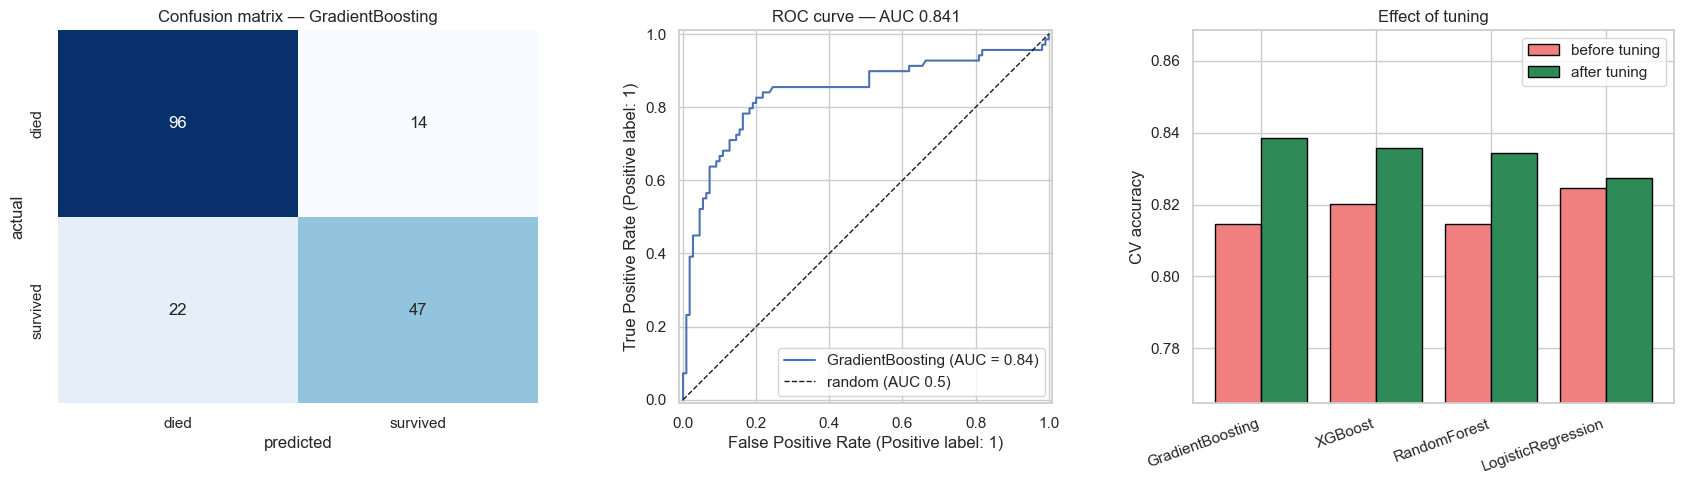

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

sns.heatmap(confusion_matrix(y_hold, y_pred), annot=True, fmt="d", cmap="Blues",
            cbar=False, xticklabels=["died","survived"],
            yticklabels=["died","survived"], ax=ax[0])
ax[0].set_title(f"Confusion matrix — {winner_name}")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual")

RocCurveDisplay.from_predictions(y_hold, y_prob, ax=ax[1], name=winner_name)
ax[1].plot([0,1],[0,1],"k--",lw=1,label="random (AUC 0.5)")
ax[1].set_title(f"ROC curve — AUC {auc:.3f}"); ax[1].legend()

pd_ = sm.dropna(subset=["cv_before"])
xp = np.arange(len(pd_))
ax[2].bar(xp-0.2, pd_.cv_before, 0.4, label="before tuning",
          color="lightcoral", edgecolor="black")
ax[2].bar(xp+0.2, pd_.cv_after, 0.4, label="after tuning",
          color="seagreen", edgecolor="black")
ax[2].set_xticks(xp); ax[2].set_xticklabels(pd_.model, rotation=20, ha="right")
_lo = min(pd_.cv_before.min(), pd_.cv_after.min())
_hi = max(pd_.cv_before.max(), pd_.cv_after.max())
ax[2].set_ylim(max(0, _lo - 0.05), min(1, _hi + 0.03)); ax[2].legend()
ax[2].set_title("Effect of tuning"); ax[2].set_ylabel(f"CV {METRIC}")

plt.tight_layout(); plt.show()

---
# Step 5 — Ship and Maintain

The step where most real projects actually fail. Not because the model was bad,
but because it was never deployed, never explained convincingly, or never
monitored.

## 5.1 Save the whole PIPELINE, not just the model

That one object contains feature engineering → imputer → encoder → scaler →
model. Saving only the model forces production to rebuild every transformation
by hand — and that **training/serving mismatch** is one of the most common ways
deployed models silently break.

In [32]:
import joblib

# Refit on ALL data now that evaluation is finished. More data, better model.
# The honest performance estimate is already locked in.
final = clone(winner).fit(X_all, y_all)
joblib.dump(final, "titanic_pipeline.pkl")

card = {"model": str(winner_name),
        "selection_metric": METRIC,
        "cv_score": round(float(winner_cv), 4),
        "holdout_score": round(float(hold_metric), 4),
        "holdout_accuracy": round(float(acc), 4),
        "holdout_precision": round(float(prec), 4),
        "holdout_recall": round(float(rec), 4),
        "holdout_auc": round(float(auc), 4),
        "holdout_mean_12_splits": round(float(accs.mean()), 4),
        "holdout_std_12_splits": round(float(accs.std()), 4),
        "holdout_metric_mean_12_splits": round(float(hs.mean()), 4),
        "holdout_metric_std_12_splits": round(float(hs.std()), 4),
        "features": f"engineered, {len(new_cols)} derived "
                    f"(ticket block OFF: measured {ticket_delta:+.4f} in 2.1)",
        "baseline": round(float(1 - y_all.mean()), 4),
        "training_rows": int(len(X_all))}

with open("model_card.json", "w") as fh:
    json.dump(card, fh, indent=2)

print("Saved titanic_pipeline.pkl containing:")
for k, v in final.named_steps.items():
    print(f"    {k:<12} {type(v).__name__}")
print("\nModel card:")
for k, v in card.items():
    print(f"    {k:<26} {v}")

Saved titanic_pipeline.pkl containing:
    features     TitanicFeatures
    prep         ColumnTransformer
    model        GradientBoostingClassifier

Model card:
    model                      GradientBoosting
    selection_metric           accuracy
    cv_score                   0.8385
    holdout_score              0.7989
    holdout_accuracy           0.7989
    holdout_precision          0.7705
    holdout_recall             0.6812
    holdout_auc                0.8412
    holdout_mean_12_splits     0.8436
    holdout_std_12_splits      0.0178
    holdout_metric_mean_12_splits 0.8436
    holdout_metric_std_12_splits 0.0178
    features                   engineered, 11 derived (ticket block OFF: measured +0.0010 in 2.1)
    baseline                   0.6162
    training_rows              891


## 5.2 Input validation

**Garbage in, garbage out — but SILENTLY.** A model handed nonsense does not
raise an error. It returns a confident, wrong prediction. Validation is the only
thing standing between you and that.

In [33]:
# Ticket is on the list even though the default pipeline ignores it: flipping
# ticket_features on must not turn a validation error into a KeyError deep in
# a transformer. Validate the contract you might need, not just today's path.
REQUIRED = ["Pclass","Name","Sex","Age","SibSp","Parch","Fare","Ticket",
            "Cabin","Embarked"]

def validate(d):
    problems = []
    missing = [c for c in REQUIRED if c not in d.columns]
    if missing:
        problems.append(f"missing columns: {missing}")
    if "Age" in d and d.Age.notna().any() and not d.Age.dropna().between(0,120).all():
        problems.append("Age outside plausible range 0-120")
    if "Fare" in d and (d.Fare.dropna() < 0).any():
        problems.append("negative Fare")
    if "Pclass" in d and not d.Pclass.isin([1,2,3]).all():
        problems.append("Pclass must be 1, 2 or 3")
    if "Sex" in d and not d.Sex.isin(["male","female"]).all():
        problems.append("Sex must be 'male' or 'female'")
    if problems:
        raise ValueError("Validation failed:\n  - " + "\n  - ".join(problems))
    return d


def predict(d, model, threshold=0.5):
    """Always return the PROBABILITY, not just the label. It lets whoever
    consumes the prediction set their own threshold based on what a false
    positive costs them. That is a business decision and does not belong
    hard-coded inside the model."""
    validate(d)
    p = model.predict_proba(d)[:, 1]
    return pd.DataFrame({"survival_probability": p.round(4),
                         "prediction": (p >= threshold).astype(int),
                         "confidence": np.where(np.abs(p-0.5) > 0.30, "high",
                                       np.where(np.abs(p-0.5) > 0.15, "medium",
                                                "low"))}, index=d.index)

print("validate() and predict() defined.")

validate() and predict() defined.


In [34]:
new = pd.DataFrame([
 {"PassengerId":9001,"Pclass":1,"Name":"Hall, Mrs. Evelyn","Sex":"female",
  "Age":34,"SibSp":1,"Parch":2,"Ticket":"PC 17599","Fare":118.5,
  "Cabin":"C85","Embarked":"C"},
 {"PassengerId":9002,"Pclass":3,"Name":"Novak, Mr. Stefan","Sex":"male",
  "Age":27,"SibSp":0,"Parch":0,"Ticket":"349245","Fare":7.9,
  "Cabin":np.nan,"Embarked":"S"},
 {"PassengerId":9003,"Pclass":2,"Name":"Ellis, Master. Thomas","Sex":"male",
  "Age":6,"SibSp":1,"Parch":2,"Ticket":"C.A. 2315","Fare":27.75,
  "Cabin":np.nan,"Embarked":"S"},
 {"PassengerId":9004,"Pclass":3,"Name":"Byrne, Miss. Nora","Sex":"female",
  "Age":np.nan,                       # missing age ON PURPOSE
  "SibSp":0,"Parch":0,"Ticket":"330959","Fare":7.88,
  "Cabin":np.nan,"Embarked":"Q"},
])

out = predict(new, final)
display(new[["Name","Pclass","Sex","Age"]].join(out))

,Name,Pclass,Sex,Age,survival_probability,prediction,confidence
0,"Hall, Mrs. Evelyn",1,female,34.0,0.9790,1,high
1,"Novak, Mr. Stefan",3,male,27.0,0.1053,0,high
2,"Ellis, Master. Thomas",2,male,6.0,0.8288,1,high
3,"Byrne, Miss. Nora",3,female,NaN,0.7178,1,medium


Read those against the EDA:

- the 1st-class woman scores highest (sex + class)
- the 3rd-class man scores lowest (sex + class)
- the boy scores far above the adult man — **`Master` caught him**
- passenger 4 has **no age at all** and still gets a sensible prediction,
  because `Title` and `Pclass` carry the signal

That last one is exactly why we engineered `Title` instead of relying on `Age`.

All four carry a `Ticket` the model has never seen. The default pipeline
ignores it — but if you switch `ticket_features` on, `GroupSize` falls back to
1 for unknown tickets and `TicketPrefix` to `OTHER`, which the encoder was
fitted with. An unseen category should degrade a prediction slightly, never
crash the service.

In [35]:
# validation catching nonsense
bad = new.copy()
bad.loc[0, "Age"] = 250
bad.loc[1, "Pclass"] = 7
try:
    predict(bad, final)
    print("no error — validation is broken")
except ValueError as e:
    print("Rejected, correctly:\n")
    print("  " + str(e).replace("\n", "\n  "))
    print("\nWithout this the model would have returned a confident probability")
    print("for a 250-year-old in a class that does not exist — with NO error.")

Rejected, correctly:

  Validation failed:
    - Age outside plausible range 0-120
    - Pclass must be 1, 2 or 3

Without this the model would have returned a confident probability
for a 250-year-old in a class that does not exist — with NO error.


## 5.3 Drift monitoring

- **Data drift** — the *inputs* change (customers get younger, a sensor is recalibrated)
- **Concept drift** — the *relationship* changes (a competitor launches; COVID broke every travel model overnight)

Data drift you can detect immediately. Concept drift you can only catch by
watching real outcomes, which may take months.

In [36]:
def check_drift(live, ref, threshold=2.0):
    out = []
    for c in ["Age","Fare","SibSp","Parch","Pclass"]:
        if c not in live.columns:
            continue
        r, cur = ref[c].dropna(), live[c].dropna()
        if len(cur) == 0 or r.std() == 0:
            continue
        z = abs(cur.mean() - r.mean()) / r.std()
        out.append({"feature":c, "train_mean":round(r.mean(),2),
                    "live_mean":round(cur.mean(),2), "z":round(z,2),
                    "status":"DRIFT" if z > threshold else "ok"})
    return pd.DataFrame(out)

normal = df.sample(120, random_state=7)
print("Case A — a normal week of live traffic:")
display(check_drift(normal, df))

drifted = normal.copy()
drifted["Age"] = drifted.Age + 38        # much older cohort
drifted["Fare"] = drifted.Fare * 6.0     # much wealthier cohort
print("Case B — the population has shifted:")
display(check_drift(drifted, df))

Case A — a normal week of live traffic:


,feature,train_mean,live_mean,z,status
0,Age,29.70,32.22,0.17,ok
1,Fare,32.20,28.14,0.08,ok
2,SibSp,0.52,0.55,0.02,ok
3,Parch,0.38,0.35,0.04,ok
4,Pclass,2.31,2.39,0.10,ok


Case B — the population has shifted:


,feature,train_mean,live_mean,z,status
0,Age,29.70,70.22,2.79,DRIFT
1,Fare,32.20,168.86,2.75,DRIFT
2,SibSp,0.52,0.55,0.02,ok
3,Parch,0.38,0.35,0.04,ok
4,Pclass,2.31,2.39,0.10,ok


Case B is what a broken upstream source, or a genuinely changed customer base,
looks like from outside. You caught it **without knowing a single true outcome.**

Also worth watching, and free:

- **the prediction distribution** — if you used to flag 38% positive and now flag
  65%, something changed even if you can't yet say what
- missing-value rates per column
- any category the encoder has never seen

**And log every prediction with a timestamp.** The most common monitoring
failure isn't bad dashboards — it's not logging at all, because then when
outcomes finally arrive you can't evaluate anything retrospectively.

## 5.4 Presenting this to a non-technical audience

In [37]:
mean_acc, std_acc, base = (card["holdout_mean_12_splits"],
                           card["holdout_std_12_splits"], card["baseline"])

print("BAD (all technique, no meaning):")
print(f'  "We achieved {card["cv_score"]:.3f} cross-validated {METRIC} with a')
print(f'   tuned classifier over {len(new_cols)} engineered features."\n')

print("GOOD (impact, honesty, next step):")
print(f'  "The model gets about {mean_acc:.0%} of cases right, give or take')
print(f'   {std_acc:.0%}. Guessing gets you {base:.0%}, so it is a real')
print('   improvement, not a restatement of the obvious.')
print('')
print('   Sex and passenger class explain most of it — first-class women')
print('   survived at over 90%, third-class men under 15%.')
print('')
print('   Where it struggles: third-class women, close to a coin flip.')
print('   If that group matters, we need better data on them rather')
print('   than a better algorithm."')

BAD (all technique, no meaning):
  "We achieved 0.839 cross-validated accuracy with a
   tuned classifier over 11 engineered features."

GOOD (impact, honesty, next step):
  "The model gets about 84% of cases right, give or take
   2%. Guessing gets you 62%, so it is a real
   improvement, not a restatement of the obvious.

   Sex and passenger class explain most of it — first-class women
   survived at over 90%, third-class men under 15%.

   Where it struggles: third-class women, close to a coin flip.
   If that group matters, we need better data on them rather
   than a better algorithm."


### The structure that works, every time

1. **Impact first**, in plain numbers, **with the uncertainty**
2. **Compare to the baseline** — or the number means nothing
3. **What drives it** — often the most useful slide
4. **Where it fails** — honesty here buys you trust later
5. **What would improve it** — usually better data, not a fancier model

---
# Summary — Where the gains actually came from

In [38]:
# Every row below is measured by this notebook, not quoted from memory.
tuned_gain = np.mean([r["cv_after"] - r["cv_before"] for r in summary
                      if r["model"] in ("RandomForest", "GradientBoosting")])
best_single = sm[sm.model != "Ensemble"]["cv_after"].max()
feat_gain = np.mean([deltas["LogisticRegression"], deltas["RandomForest (depth 6)"]])

gains = pd.DataFrame([
    ("Baseline -> any real model",     (mean_acc - base) * 100),
    ("Raw -> engineered features",     feat_gain * 100),
    ("Ticket block (measured, NOT shipped)", ticket_delta * 100),
    ("Untuned -> tuned trees",         tuned_gain * 100),
    ("Best single model -> ensemble",  (ens_cv - best_single) * 100),
], columns=["change", "gain (pts)"])
display(gains.round(2))

print("Notice the shape of that table.")
print("The unglamorous work \u2014 framing the problem, reading the data,")
print("controlling overfitting \u2014 produced almost everything.")
print("The ensemble, the most sophisticated step, produced nothing.")
print("\nThat ratio is typical of real projects.")
print("\nAnd note how many of those rows are SMALLER than the fold-to-fold")
print(f"noise of about {noise:.3f}. Only the first one is unambiguously real.")


,change,gain (pts)
0,Baseline -> any real model,22.74
1,Raw -> engineered features,1.41
2,"Ticket block (measured, NOT shipped)",0.10
3,Untuned -> tuned trees,2.18
4,Best single model -> ensemble,-0.42


Notice the shape of that table.
The unglamorous work — framing the problem, reading the data,
controlling overfitting — produced almost everything.
The ensemble, the most sophisticated step, produced nothing.

That ratio is typical of real projects.

And note how many of those rows are SMALLER than the fold-to-fold
noise of about 0.021. Only the first one is unambiguously real.


## Ten principles this project is built on

1. **Establish a baseline before anything else.** You cannot judge a model without one.
2. **Split before you explore.** Snooping bias contaminates your judgement, not just your code.
3. **Missingness can be a feature.** `HasCabin` gave a large survival gap.
4. **Feature engineering beats algorithm choice** — but only with matched regularisation.
5. **Use a Pipeline.** It makes leakage structurally impossible.
6. **Read the standard deviation.** Overlapping ranges mean the difference isn't real.
7. **The train–CV gap is the overfitting diagnostic**, not the raw training score.
8. **Touch the test set exactly once.**
9. **A single split is noisy.** Measure the spread before trusting any number.
10. **Deploy the pipeline and monitor it.** Models decay; unmonitored models fail silently.
11. **A metric is a choice, not a default.** "Best model" only means anything once you have said best at what.

---

## Making it your own

Three of the five suggestions that used to sit here are now built in:

- **Ticket prefix and shared-ticket group size** are engineered in Step 2 and
  measured in **2.1**. On the stand-in they do not clear the fold-to-fold
  noise, so they default to `False` — the notebook follows its own verdict
  rather than keeping a feature it likes the sound of
- **The metric is a variable.** `METRIC` in the setup cell drives comparison,
  tuning and selection; **3.1b** re-ranks every model under accuracy, F1 and AUC
- **XGBoost and LightGBM** join the comparison and the search automatically if
  they are installed (`pip install xgboost lightgbm`)

What is left is the part only you can do:

1. Upload the real Kaggle `train.csv` and compare every number above. The
   stand-in reproduces the real dataset's structure, but 2.1 in particular
   deserves re-running against real ticket numbers.
2. Set `METRIC = "roc_auc"`, re-run from Step 3, and see how much of the
   ranking survives.
3. Add a feature of your own and put it through the 2.1 experiment. If the
   delta does not clear the fold-to-fold std, say so.
4. **Apply this identical structure to a completely different dataset.**

That last one is the real test. The structure transfers; the dataset doesn't.